# Импорты и зависимости

In [43]:
!pip install yfinance 1>/dev/null

In [44]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Подготовка данных

In [45]:
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01", progress=False, auto_adjust=True)["Close"].values
print(f"Загружено {len(data)} цен закрытия акций Apple")

dim = 64
base_signal = data[:dim].astype(np.float32)
base_signal = (base_signal - base_signal.mean()) / base_signal.std()
base_signal = base_signal[:, 0]

np.random.seed(42)
torch.manual_seed(42)
n_samples = 500

normal = base_signal[None, :] + np.random.normal(0, 0.1, (n_samples, dim))

anomalous = base_signal[None, :] + np.random.normal(0, 0.1, (n_samples, dim))
for i in range(n_samples // 2):
    pos = np.random.randint(0, dim)
    anomalous[i, pos] += 5.0
anomalous[n_samples//2:] += 2.0

X_np = np.vstack([normal, anomalous])
y_np = np.array([0]*n_samples + [1]*n_samples)
idx = np.random.permutation(len(X_np))
X_np = X_np[idx]
y_np = y_np[idx]

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

Загружено 1006 цен закрытия акций Apple


# Класс модели

In [46]:
class Encoder(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_layers=8):
        super().__init__()
        self.num_layers = num_layers
        self.layer_list = nn.ModuleList()
        current_dim = input_dim
        for _ in range(num_layers):
            self.layer_list.append(nn.Linear(current_dim, hidden_dim))
            current_dim = hidden_dim
        self.relu = nn.ReLU()
    def forward(self, x):
        activations = []
        for layer in self.layer_list:
            x = self.relu(layer(x))
            activations.append(x.clone())
        return activations

class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_layers=8):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
    def forward(self, x):
        activations = self.encoder(x)
        recon = self.decoder(activations[-1])
        return recon, activations

# Эксперименты

## Обучение модели

In [47]:
ae = Autoencoder()
optimizer = torch.optim.Adam(ae.parameters(), lr=0.01)
criterion = nn.MSELoss()

print('Обучаем автоэнкодер')
for epoch in range(300):
    optimizer.zero_grad()
    recon, _ = ae(X)
    loss = criterion(recon, X)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Обучаем автоэнкодер
Epoch 0, Loss: 2.0838
Epoch 100, Loss: 0.1083
Epoch 200, Loss: 0.1072


## Считаем метрики для слоёв


=== Metrics per Layer ===
Layer | KL Divergence (sensitivity) | LDR (separability) | Entropy (concentration)
    0 |                0.2633 |             0.0172 |       0.0641
    1 |                1.0415 |             0.5114 |       0.2644
    2 |                1.8710 |             0.7572 |       1.0439
    3 |                2.0113 |             0.2893 |       0.6428
    4 |                0.7043 |             0.5066 |       0.0805
    5 |                1.8888 |             0.4615 |       0.7889
    6 |                0.7808 |             0.1982 |       0.7991
    7 |                1.2124 |             0.3140 |       1.7663


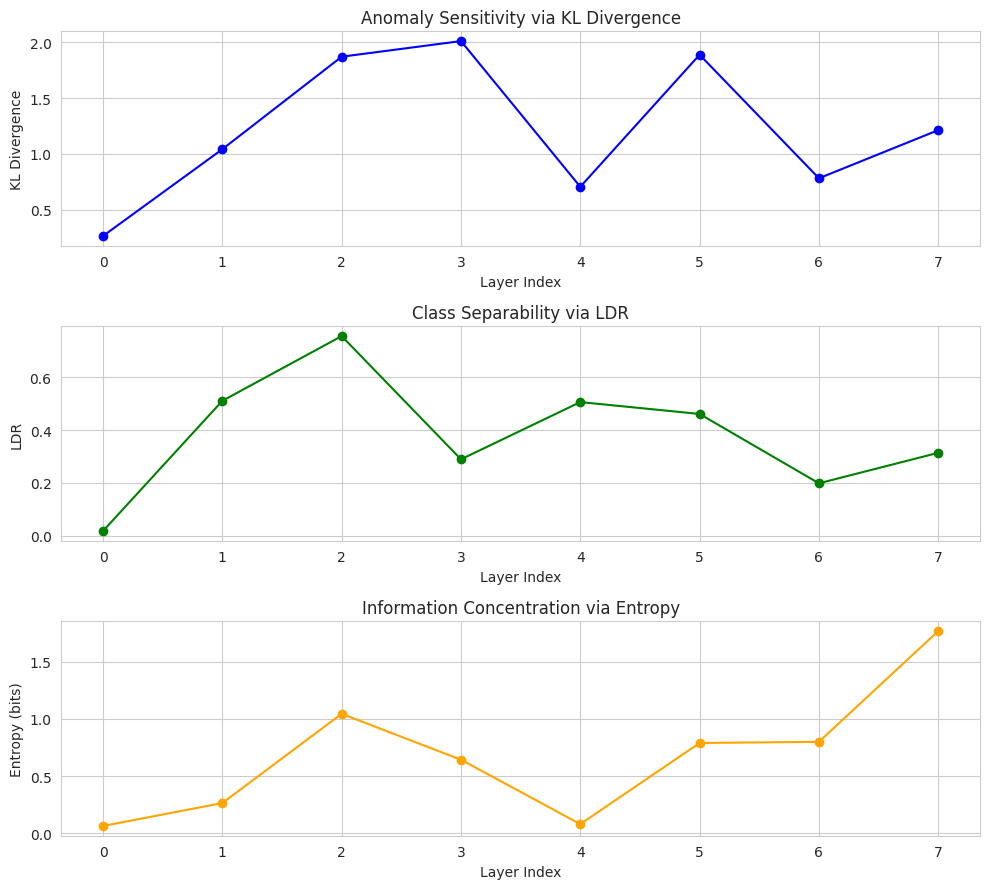

In [51]:
with torch.no_grad():
    _, activations = ae(X)

layers = list(range(len(activations)))
kl_list = []
ldr_list = []
ent_list = []

for l_idx in layers:
    h_l = activations[l_idx].numpy()
    h_n = h_l[y.numpy() == 0]
    h_a = h_l[y.numpy() == 1]
    D = h_l.shape[1]
    kl = 0.0
    ldr = 0.0

    h_all = h_l.flatten()
    hist, _ = np.histogram(h_all, bins=50, range=(np.min(h_all), np.max(h_all)))
    p = hist / np.sum(hist) + 1e-10
    ent = -np.sum(p * np.log2(p))

    for d in range(D):
        mu_n = np.mean(h_n[:, d])
        mu_a = np.mean(h_a[:, d])
        sigma_n2 = np.var(h_n[:, d]) + 1e-8
        sigma_a2 = np.var(h_a[:, d]) + 1e-8

        ldr_d = (mu_n - mu_a)**2 / (sigma_n2 + sigma_a2)
        ldr += ldr_d

        term1 = np.log(sigma_a2 / sigma_n2)
        term2 = (sigma_n2 + (mu_n - mu_a)**2) / sigma_a2
        kl_d = 0.5 * (term1 + term2 - 1)
        kl += kl_d
    ldr /= D
    kl /= D
    kl_list.append(kl)
    ldr_list.append(ldr)
    ent_list.append(ent)

print('\n=== Metrics per Layer ===')
print('Layer | KL Divergence (sensitivity) | LDR (separability) | Entropy (concentration)')
for l, k, ld, e in zip(layers, kl_list, ldr_list, ent_list):
    print(f'{l:5} | {k:21.4f} | {ld:18.4f} | {e:12.4f}')

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(10, 9))
axs[0].plot(layers, kl_list, marker='o', color='blue')
axs[0].set_title('Anomaly Sensitivity via KL Divergence')
axs[0].set_xlabel('Layer Index')
axs[0].set_ylabel('KL Divergence')
axs[1].plot(layers, ldr_list, marker='o', color='green')
axs[1].set_title('Class Separability via LDR')
axs[1].set_xlabel('Layer Index')
axs[1].set_ylabel('LDR')
axs[2].plot(layers, ent_list, marker='o', color='orange')
axs[2].set_title('Information Concentration via Entropy')
axs[2].set_xlabel('Layer Index')
axs[2].set_ylabel('Entropy (bits)')
plt.tight_layout()

## Смотрим, как хорошо по слою можно отличить нормальное от аномального

In [49]:
def train_probe(h, y_train, epochs=300, lr=0.01):
    probe = nn.Linear(h.shape[1], 2)
    opt = torch.optim.Adam(probe.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad()
        logits = probe(h)
        loss = crit(logits, y_train)
        loss.backward()
        opt.step()
    with torch.no_grad():
        pred = torch.argmax(probe(h), dim=1)
        acc = (pred == y_train).float().mean().item() * 100
    return acc


In [50]:
print('\n=== Linear Probe Accuracy (%) on Selected Layers (full data for toy eval) ===')
sorted_idxs = sorted(range(len(ldr_list)), key=lambda i: ldr_list[i], reverse=True)
for l in sorted_idxs:
    h = activations[l]
    acc = train_probe(h, y)
    print(f'Layer {l} (top LDR): {acc:.2f}%')


=== Linear Probe Accuracy (%) on Selected Layers (full data for toy eval) ===
Layer 2 (top LDR): 94.00%
Layer 1 (top LDR): 94.10%
Layer 4 (top LDR): 92.10%
Layer 5 (top LDR): 88.70%
Layer 7 (top LDR): 82.80%
Layer 3 (top LDR): 92.70%
Layer 6 (top LDR): 89.10%
Layer 0 (top LDR): 91.30%


# Итог

Получилось, что лучше всего аномалии отслеживать через 1 и 2 слои, а хуже всего через 0 и 6. Выходит, что финальный слой уже потерял часть информации, важной для обнаружения аномалий, а начальный ещё не агрегировал поданную информацию правильно. Вот и вышло, что компромисс посередине